[17:25:55] (load_picam_data) Loading picamera data for experiment 20250226_e01

[17:25:55] (find_picams) 2 picamera(s) found: ['pic1', 'pic2']

[17:25:55] (load_picam_metadata) pic1 metadata loaded!
[17:25:55] (load_picamera_clock_data) pic1 frame time data loaded!
[17:25:55] (load_picam_LED_data) LED intensity values loaded!

[17:25:55] (load_picam_metadata) pic2 metadata loaded!
[17:25:55] (load_picamera_clock_data) pic2 frame time data loaded!
[17:25:55] (load_picam_LED_data) LED intensity values loaded!

[17:25:55] (load_picam_data) PICAM Acquisition SUMMARY:

   Metadata (pic1):
   Framerate [fps]: 40.0
   Video duration [min]: 1.0
   Resolution [px]: (1280, 720)
   Shutter speed [us]: 3000.0
   Bitrate [bit/sec]: 7000000

   Metadata (pic2):
   Framerate [fps]: 40.0
   Video duration [min]: 1.0
   Resolution [px]: (1280, 720)
   Shutter speed [us]: 3000.0
   Bitrate [bit/sec]: 7000000


[17:25:55] (analyze_picam_times) Analyzing picam frame times for experiment 20250226_e01:

Fra

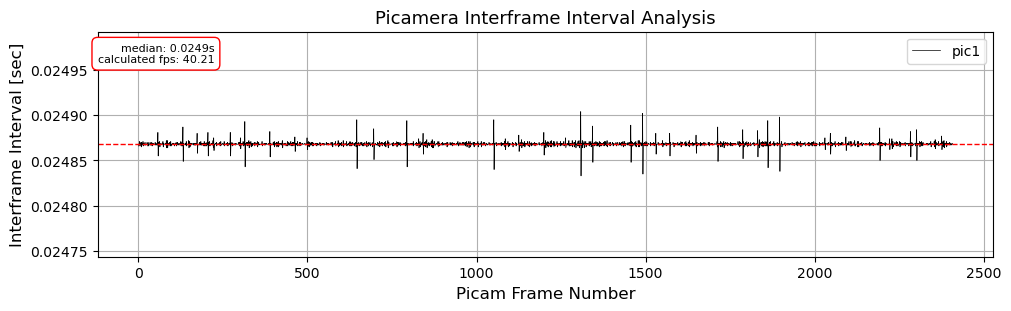


Frame analysis for pic2:
   Total number of picam frames found: 2408
   Total number of dropped picam frames: 0


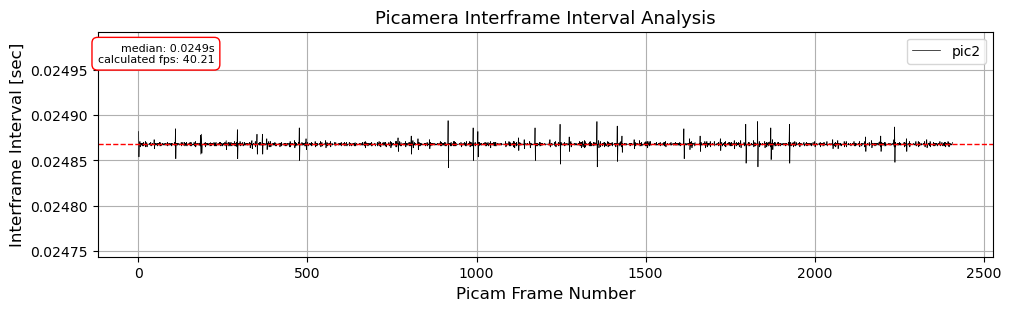


[17:25:55] (analyze_picam_times) Analysis of picam frame timing completed for experiment 20250226_e01.


[17:25:55] (load_daq_data) Loading DAQ data for experiment 20250226_e01

[17:25:56] (load_daq_data) Loaded: daq_arduino_voltage.csv

-------------------------------------------------------------------------------------------------------------

[17:25:56] (synchronize_daq_picameras) Synchronizing DAQ and PiCamera data for experiment 20250226_e01
                                   using ROI intensity-voltage matching of the same blinking LED.

[17:25:56] (initialize_sync_dict) Calculate lag between DAQ signal and pic1 using cross-correlation.


IndexError: index 6549 is out of bounds for axis 0 with size 5987

In [1]:
# Standard library imports
import getpass
import matplotlib.pyplot as plt

from modules import picam_data_loader
from modules import picam_data_analysis
from modules import daq_data_loader
from modules import sync_daq_picam 

user = getpass.getuser()
#datadir    = '/home/' + user + '/Desktop/picam_sync_neuro/testdata/'
datadir    = '/media/' + user + '/DATA/picam_sync_neuro/testdata/'

expID      = '20250226_e01'

picam_dict = picam_data_loader.load_picam_data(datadir, expID, verbose=True)
picam_dict = picam_data_analysis.analyze_picam_times(datadir, expID, picam_dict, verbose=True)

daq_dict = daq_data_loader.load_daq_data(datadir, expID, daq_frequency=3000)

sync_dict = sync_daq_picam.synchronize_daq_picameras(datadir, expID, picam_dict, daq_dict, verbose=True)

sync_daq_picam.plot_picam_daq_sync_data(datadir, expID, picam_dict, daq_dict, sync_dict, xmin=6500, xmax=6540)

In [3]:
picam_LEDsignal = picam_dict['pic1']['picam_timing']['picam_LEDsignal']

arduino_voltage = daq_dict['daq_timing']['arduino_voltage_df']

In [5]:
new_timebase_s=0.01

df1_resampled = sync_daq_picam.resample_signal(picam_LEDsignal, 'frame_time_sec', 'LED_ROI_avg', new_timebase_s)
df2_resampled = sync_daq_picam.resample_signal(arduino_voltage,    'daq_time_sec', 'voltage',     new_timebase_s)

In [6]:
df1_resampled

,frame_time_sec,LED_ROI_avg
0,0.00,3.055568
1,0.01,2.997862
2,0.02,2.940157
3,0.03,2.873220
4,0.04,2.797536
...,...,...
5982,59.82,1.164386
5983,59.83,1.204866
5984,59.84,1.215235
5985,59.85,1.214540


In [7]:
df2_resampled

,daq_time_sec,voltage
0,352.419712,1.00000
1,352.429712,1.00000
2,352.439712,1.00000
3,352.449712,1.00000
4,352.459712,1.00000
...,...,...
19200,544.419712,1.00000
19201,544.429712,1.00000
19202,544.439712,1.00000
19203,544.449712,0.00002
